# Regression track — delivery lead time (dual framing)

**Problem.** For each order approved on the inference date, predict how many calendar days it will take from approval to customer delivery.
- Stakeholder: customer service / fulfilment planning. They get a day-level delay estimate that complements the late/on-time flag from `model_classification_dev.ipynb`.
- Dual framing (Example 4 of the brief): the same underlying outcome drives both tasks.
  - Regression predicts the lead time.
  - Classification predicts whether the lead time exceeds the promised lead time.

**What this notebook covers.** The layout follows `model_classification_dev.ipynb`:
1. Target definition, plus a censoring/horizon audit. This mirrors the classification buffer audit.
2. Training data at one run date, using the same `get_required_dates` window as classification.
3. A chronological hold-out (the newest 45 approval days) and day-blocked time-series CV on the remaining days.
4. Cross-validated defaults for two families, next to two reference baselines:
   - References: Dummy median and Olist's own promised lead time.
   - Linear family: Linear Regression → Ridge.
   - Tree-based family: Decision Tree → Random Forest → LightGBM.
5. Hyperparameter tuning with `RandomizedSearchCV` on the same folds.
6. **Champion selection.** The champion is the candidate (default or tuned) with the lowest CV MAE so far. Every later section uses it.
7. Hold-out evaluation, permutation importance and residuals for the champion.
8. The late flag derived from the champion's output, compared with a classifier.
9. A pooled monthly backtest on a moving window. The champion is re-selected at each monthly run date.

Shared code lives in `phase2/src/`. The tuned parameters and the champion are saved to `results/regression_tuning.json`.

# Updates
- 20260927 - Initial regression pipeline, src/ extraction, chronological CV
- 20261003 - Restructured to follow `model_classification_dev.ipynb`:
    - Default vs tuned for every model, and a champion chosen by CV MAE
    - Hold-out lengthened from 30 to 45 days
    - Monthly backtest re-selects the champion at each run date and pools April–July 2018

# Environment set-up

In [1]:
import json, os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('.') if os.path.isdir('src') else os.path.abspath('phase2'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from joblib import Parallel, delayed

from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

from src import RANDOM_STATE, LOOKBACK, PXD
from src.data import load_olist_data
from src.features import (build_feature_table, add_extra_features,
                          NUM_COLS, CAT_COLS, EXTRA_NUM_COLS, LEAKAGE_COLS)
from src.labels import (get_required_dates, labels_as_of, regression_targets_as_of,
                        attach_regression_actuals)
from src.splits import chronological_split, day_blocked_time_series_folds
from src.evaluation import regression_metrics, classification_metrics

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(RANDOM_STATE)

# Constants

In [2]:
RUN_DATE = '2018-06-02'   # Same run date as model_classification_dev.ipynb
HORIZON = LOOKBACK        # Cap for the lead-time target, chosen in the horizon audit below
TEST_DAYS = 45            # Newest approval days held out as the test set
N_CV_FOLDS = 5
# Random-search iterations per model; kept small for laptop run times
N_ITER = {'Ridge': 12, 'Decision Tree': 15, 'Random Forest': 6, 'LightGBM': 10}
BACKTEST_RUN_DATES = ['2018-04-02', '2018-05-02', '2018-06-02', '2018-07-02']
EXCLUDED_STATUSES = ['canceled', 'unavailable']  # Never delivered: not a lead-time outcome

REG_NUM_COLS = NUM_COLS + EXTRA_NUM_COLS
REG_FEATURE_COLS = REG_NUM_COLS + CAT_COLS
assert not set(REG_FEATURE_COLS) & set(LEAKAGE_COLS), 'Outcome columns used as features'

# Load data and build features

In [3]:
olist = load_olist_data()
orders = olist['orders']
final_df = add_extra_features(build_feature_table(olist), olist)
print(f'Shape: {final_df.shape}; unique orders: {final_df["order_id"].nunique():,}')

Extracting /Users/mushroomyyy/Documents/Team8_IT5006_Ecommerce_Analytics_AY2627Sem1/streamlit_release/data/olist_csv.zip -> /Users/mushroomyyy/Documents/Team8_IT5006_Ecommerce_Analytics_AY2627Sem1/Olist_CSV


Loaded orders: 99,441 rows × 8 cols
Loaded order_items: 112,650 rows × 7 cols


Loaded customers: 99,441 rows × 5 cols
Loaded products: 32,951 rows × 9 cols
Loaded sellers: 3,095 rows × 4 cols
Loaded payments: 103,886 rows × 5 cols


Loaded reviews: 99,224 rows × 7 cols


Loaded geolocation: 1,000,163 rows × 5 cols
Loaded category_translation: 71 rows × 2 cols


Shape: (98959, 61); unique orders: 98,959


# Target definition and horizon audit
**Target:** `lead_days` = customer delivery date − approval date, in calendar days, capped at `HORIZON`:

$$y = \min(\text{lead\_days},\ H)$$

**Why a cap?** At run date *R*, an order approved on day *d* has been observed for only *R − d* days.
- A slow order that is still undelivered has no lead time yet, so it is **right-censored**.
- The v2 classification labels count these orders as late (`late_undelivered`: 1,150 orders at 2018-06-02).
- Dropping them from a regression would remove exactly the worst deliveries and bias predictions downward.

With the cap, a still-undelivered order that is already *H* days old is known to have y = H. Every training order is at least `LOOKBACK` + 1 days old, so with *H* ≤ `LOOKBACK` the capped target is **fully observed for every valid training order**, using only information before the run date.

**Population.** Canceled and unavailable orders never get delivered, so they have no lead time; they are excluded. Orders that were shipped but never delivered are kept and capped.
- Limitation: the dataset only stores each order's final status, so the exclusion uses that snapshot. In training windows (≥ 46 days old) the cancellation would normally already be known.
- At inference time these orders are scored like any other.

In [4]:
delivered = final_df['order_delivered_customer_date'].notna()
lead_days = (final_df['order_delivered_customer_date'].dt.normalize() - final_df['order_approved_dt']).dt.days
display(lead_days[delivered].describe(percentiles=[.5, .75, .9, .95, .99]).to_frame('lead_days (delivered)'))

audit_rows = []
for run_date in ['2018-02-01', '2018-04-01', '2018-06-01', '2018-08-01']:
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    window = final_df[final_df['order_approved_dt'].between(start, end)
                      & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    for horizon in [21, 30, 45]:
        targets = regression_targets_as_of(window, run_date=run_date, horizon=horizon)
        status = targets['target_status'].value_counts(normalize=True) * 100
        audit_rows.append({'run_date': run_date, 'horizon': horizon, 'orders': len(targets),
                           'known_pct': 100 * targets['target_as_of_run'].notna().mean(),
                           'capped_pct': status.get('capped_delivered', 0) + status.get('capped_undelivered', 0),
                           'unresolved_pct': status.get('unresolved', 0)})
horizon_audit = pd.DataFrame(audit_rows)
display(horizon_audit.round(2))

,lead_days (delivered)
count,96190.000
mean,11.965
std,9.510
min,-7.000
50%,10.000
75%,15.000
90%,22.000
95%,29.000
99%,45.000
max,208.000


,run_date,horizon,orders,known_pct,capped_pct,unresolved_pct
0,2018-02-01,21,29093,99.970,12.940,0
1,2018-02-01,30,29093,99.970,5.900,0
2,2018-02-01,45,29093,99.970,2.700,0
3,2018-04-01,21,33643,99.970,15.570,0
4,2018-04-01,30,33643,99.970,6.820,0
5,2018-04-01,45,33643,99.970,2.820,0
6,2018-06-01,21,39387,99.990,19.770,0
7,2018-06-01,30,39387,99.990,9.090,0
8,2018-06-01,45,39387,99.990,3.470,0
9,2018-08-01,21,39735,99.990,16.460,0


**Reading the audit.**
- At *H* = 45, about 1% of *delivered* orders exceed the cap. Counting shipped-but-never-delivered orders too, 2.7–3.5% of training orders are capped. Every valid target is known.
- At *H* = 30, 6–9% of training orders are capped, and at *H* = 21, 13–20%. That loses detail in exactly the long-delay tail the stakeholder cares about.
- **Decision: `HORIZON = LOOKBACK = 45`.** One buffer then serves both tasks.

# Training data at the run date

In [5]:
train_test_start_date, train_test_end_date, inference_date = get_required_dates(
    RUN_DATE, lookback=LOOKBACK, pXd=PXD)
window = final_df[final_df['order_approved_dt'].between(train_test_start_date, train_test_end_date)]
excluded = window['order_status'].isin(EXCLUDED_STATUSES)
print(f'Excluded never-delivered orders ({", ".join(EXCLUDED_STATUSES)}): {excluded.sum():,}')

reg_audit = regression_targets_as_of(window[~excluded], run_date=RUN_DATE, horizon=HORIZON)
display(reg_audit['target_status'].value_counts().to_frame('orders'))
reg_df = reg_audit[reg_audit['target_as_of_run'].notna()].copy()
reg_df['y'] = reg_df['target_as_of_run'].astype(float)
print(f'Training/test orders with a known target: {len(reg_df):,}')

# The classification label for the same orders, for the dual-framing comparison later
reg_df['late_label'] = labels_as_of(reg_df, run_date=RUN_DATE)['label_as_of_run']

Train-test period for the inference date of 2018-06-01 with buffer of 45 days:
    2017-10-20 to 2018-04-17 (180 days)
Excluded never-delivered orders (canceled, unavailable): 426


,orders
target_status,
delivered_within_horizon,38159
capped_undelivered,727
capped_delivered,646
invalid_or_missing_dates,2


Training/test orders with a known target: 39,532


# Chronological split and CV folds
- **Test:** the last `TEST_DAYS` (45) approval days of the window.
- **Train:** everything before that.
- **CV:** 5 expanding-window folds on the training part. No approval day is split across train and validation.

Each CV fold is cumulative. It simulates training a model at a later date, using all orders available before that date to predict the next period:
- Fold 1: Train [A]         → Validate [B]
- Fold 2: Train [A B]       → Validate [C]
- Fold 3: Train [A B C]     → Validate [D]
- Fold 4: Train [A B C D]   → Validate [E]
- Fold 5: Train [A B C D E] → Validate [F]

This is the same `chronological_split` and `day_blocked_time_series_folds` the classification notebook uses. The window itself moves with the run date; see the monthly backtest below.

In [6]:
train_df, test_df = chronological_split(reg_df, date_col='order_approved_dt', test_days=TEST_DAYS)
train_df = train_df.sort_values('order_approved_dt', kind='stable')
X_train, y_train = train_df[REG_FEATURE_COLS], train_df['y']
X_test, y_test = test_df[REG_FEATURE_COLS], test_df['y']
print(f'Train: {train_df["order_approved_dt"].min():%Y-%m-%d} to {train_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(train_df):,} orders, mean y {y_train.mean():.2f})')
print(f'Test:  {test_df["order_approved_dt"].min():%Y-%m-%d} to {test_df["order_approved_dt"].max():%Y-%m-%d} '
      f'({len(test_df):,} orders, mean y {y_test.mean():.2f})')

# Expanding-window folds on the training part; no approval day is split across folds
cv_folds = day_blocked_time_series_folds(train_df['order_approved_dt'], n_splits=N_CV_FOLDS)
display(pd.DataFrame([{
            'fold': k, 'train_orders': len(tr), 'valid_orders': len(va),
            'valid_from': train_df['order_approved_dt'].iloc[va].min().date(),
            'valid_to': train_df['order_approved_dt'].iloc[va].max().date(),
            'valid_mean_y': round(y_train.iloc[va].mean(), 2),
                  } for k, (tr, va) in enumerate(cv_folds, 1)]
            ).set_index('fold')
      )

Train: 2017-10-20 to 2018-03-03 (29,247 orders, mean y 14.86)
Test:  2018-03-04 to 2018-04-17 (10,285 orders, mean y 14.39)


,train_orders,valid_orders,valid_from,valid_to,valid_mean_y
fold,,,,,
1,3307,6602,2017-11-12,2017-12-04,15.460
2,9909,4354,2017-12-05,2017-12-27,15.090
3,14263,4676,2017-12-28,2018-01-18,13.570
4,18939,4954,2018-01-19,2018-02-09,14.720
5,23893,5354,2018-02-10,2018-03-03,16.900


# Models
Two families across the whole project, as the brief's model-family budget requires. Each starts from its simplest variant:

| Family | Baseline | More complex |
|---|---|---|
| Linear | Linear Regression | Ridge |
| Tree-based | Decision Tree | Random Forest, LightGBM |

There are also two reference baselines. They are scored everywhere but can never be the champion:
- `DummyRegressor(median)`.
- **Olist promise**: predict the promised lead time, capped at *H*. This is the bar that matters to the business: *does the model estimate delivery better than the date Olist already shows the customer?*

All preprocessing is fitted inside each pipeline:
- Median imputation, with scaling for the linear models only.
- One-hot encoding of categorical columns.

In [7]:
def make_preprocessor(scale):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale:
        numeric_steps.append(('scaler', StandardScaler()))
    return ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), REG_NUM_COLS),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CAT_COLS),
    ], sparse_threshold=0)

def make_pipeline(model, scale=False):
    return Pipeline([('preprocessor', make_preprocessor(scale)), ('model', model)])

class PromiseBaseline(DummyRegressor):
    """Predicts Olist's promised lead time (capped at HORIZON); ignores training targets."""
    def fit(self, X, y, sample_weight=None):
        return super().fit(X, y)
    def predict(self, X):
        return np.clip(X['promised_lead_days'].to_numpy(dtype=float), 0, HORIZON)

reference_models = {
    'Dummy (median)': DummyRegressor(strategy='median'),
    'Olist promise': PromiseBaseline(),
}

MODEL_FAMILY = {
    'Linear Regression': 'Linear',
    'Ridge': 'Linear',
    'Decision Tree': 'Tree-based',
    'Random Forest': 'Tree-based',
    'LightGBM': 'Tree-based',
}

# Models use n_jobs=1 so parallelism happens only across CV folds/candidates,
# which avoids oversubscribing CPU cores.
default_models = {
    'Linear Regression': make_pipeline(LinearRegression(), scale=True),
    'Ridge': make_pipeline(Ridge(), scale=True),
    'Decision Tree': make_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    'Random Forest': make_pipeline(RandomForestRegressor(n_estimators=100, max_depth=10,
                                                         random_state=RANDOM_STATE, n_jobs=1)),
    'LightGBM': make_pipeline(LGBMRegressor(random_state=RANDOM_STATE, verbosity=-1, n_jobs=1)),
}

# Small random-search spaces; widen them once the feature set is frozen.
# Linear Regression has nothing to tune.
SEARCH_SPACES = {
    'Ridge': {'model__alpha': np.logspace(-2, 3, 12)},
    'Decision Tree': {'model__max_depth': [4, 6, 8, 10, 12, None],
                      'model__min_samples_leaf': [1, 20, 50, 100, 200]},
    'Random Forest': {'model__n_estimators': [100, 200],
                      'model__max_depth': [8, 12, 16],
                      'model__min_samples_leaf': [10, 30, 60],
                      'model__max_features': [0.3, 0.5]},
    'LightGBM': {'model__n_estimators': [200, 400, 600],
                 'model__learning_rate': [0.02, 0.05, 0.1],
                 'model__num_leaves': [15, 31, 63],
                 'model__min_child_samples': [20, 50, 100],
                 'model__subsample': [0.7, 1.0], 'model__subsample_freq': [1],
                 'model__colsample_bytree': [0.6, 0.8, 1.0],
                 'model__objective': ['regression', 'regression_l1']},
}

## Cross-validated defaults
- **MAE** is the primary metric. It reads directly as "days off".
- RMSE and R² are reported alongside it.

In [8]:
SCORING = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

def cv_summary(model, X, y, folds, n_jobs=-1):
    """Mean and standard deviation of each CV score across the given folds."""
    scores = cross_validate(model, X, y, cv=folds, scoring=SCORING, n_jobs=n_jobs)
    row = {}
    for metric in SCORING:
        values = scores[f'test_{metric}'] * (1 if metric == 'r2' else -1)
        row[f'cv_{metric}_mean'], row[f'cv_{metric}_std'] = values.mean(), values.std()
    return row

cv_rows = []
for name, model in reference_models.items():
    cv_rows.append({'model': name, 'variant': 'reference', 'family': 'Reference',
                    **cv_summary(model, X_train, y_train, cv_folds)})
for name, model in default_models.items():
    cv_rows.append({'model': name, 'variant': 'default', 'family': MODEL_FAMILY[name],
                    **cv_summary(model, X_train, y_train, cv_folds)})
display(pd.DataFrame(cv_rows).set_index(['model', 'variant']))

,,family,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
model,variant,,,,,,,
Dummy (median),reference,Reference,7.620,0.709,10.804,0.948,-0.113,0.062
Olist promise,reference,Reference,12.670,1.642,14.142,1.522,-0.995,0.597
Linear Regression,default,Linear,7.921,1.712,10.301,1.809,-0.071,0.483
Ridge,default,Linear,7.851,1.759,10.286,1.797,-0.069,0.485
Decision Tree,default,Tree-based,8.748,0.426,12.483,0.466,-0.499,0.134
Random Forest,default,Tree-based,6.342,0.427,9.003,0.725,0.225,0.058
LightGBM,default,Tree-based,6.247,0.476,8.944,0.733,0.235,0.059


### How much does a random split flatter the scores?
This scores the same default LightGBM with random 5-fold CV on the same rows. The gap from the time-series CV is the optimism that comes from training on orders that come after some of the validation orders.

In [9]:
random_cv = cv_summary(default_models['LightGBM'], X_train, y_train,
                       KFold(5, shuffle=True, random_state=RANDOM_STATE))
time_cv = next(row for row in cv_rows if row['model'] == 'LightGBM')
display(pd.DataFrame({'random 5-fold': random_cv, 'time-series 5-fold': time_cv})
        .loc[['cv_mae_mean', 'cv_rmse_mean', 'cv_r2_mean']].astype(float))

,random 5-fold,time-series 5-fold
cv_mae_mean,5.869,6.247
cv_rmse_mean,8.264,8.944
cv_r2_mean,0.339,0.235


# Hyperparameter Tuning
1. **Hyperparameter tuning** with `RandomizedSearchCV` on the time-series folds, minimising **MAE**.
2. **Champion selection.** The champion is the default or tuned candidate with the lowest CV MAE.
3. **Default vs tuned, compared on:**
   - the hold-out;
   - a pooled monthly backtest (April–July 2018) on a moving window.

## Random search
Each model searches a small grid (`SEARCH_SPACES` above) on the time-series folds, minimising mean MAE.
- Linear Regression has no hyperparameters, so it has a default variant only.
- The hold-out is never used for selection.

In [10]:
tuned_models, best_params = {}, {}
for name, space in SEARCH_SPACES.items():
    search = RandomizedSearchCV(default_models[name], space, n_iter=N_ITER[name], cv=cv_folds,
                                scoring='neg_mean_absolute_error', random_state=RANDOM_STATE,
                                n_jobs=-1, refit=False)
    search.fit(X_train, y_train)
    best_params[name] = {key: (value.item() if isinstance(value, np.generic) else value)
                         for key, value in search.best_params_.items()}
    tuned_models[name] = clone(default_models[name]).set_params(**search.best_params_)
    cv_rows.append({'model': name, 'variant': 'tuned', 'family': MODEL_FAMILY[name],
                    **cv_summary(tuned_models[name], X_train, y_train, cv_folds)})
    print(f'{name}: {best_params[name]}')

cv_results = pd.DataFrame(cv_rows).set_index(['model', 'variant']).sort_index()
display(cv_results)
display((cv_results.xs('default', level='variant')['cv_mae_mean']
         - cv_results.xs('tuned', level='variant')['cv_mae_mean'])
        .dropna().rename('cv_mae_reduction_from_tuning').to_frame())

Ridge: {'model__alpha': 1000.0}


Decision Tree: {'model__min_samples_leaf': 200, 'model__max_depth': 12}


Random Forest: {'model__n_estimators': 200, 'model__min_samples_leaf': 10, 'model__max_features': 0.3, 'model__max_depth': 12}


LightGBM: {'model__subsample_freq': 1, 'model__subsample': 0.7, 'model__objective': 'regression_l1', 'model__num_leaves': 63, 'model__n_estimators': 600, 'model__min_child_samples': 50, 'model__learning_rate': 0.02, 'model__colsample_bytree': 0.6}


family  cv_mae_mean  cv_mae_std  \
model             variant                                          
Decision Tree     default    Tree-based        8.748       0.426   
                  tuned      Tree-based        6.404       0.443   
Dummy (median)    reference   Reference        7.620       0.709   
LightGBM          default    Tree-based        6.247       0.476   
                  tuned      Tree-based        6.117       0.573   
Linear Regression default        Linear        7.921       1.712   
Olist promise     reference   Reference       12.670       1.642   
Random Forest     default    Tree-based        6.342       0.427   
                  tuned      Tree-based        6.231       0.435   
Ridge             default        Linear        7.851       1.759   
                  tuned          Linear        7.467       1.553   

                             cv_rmse_mean  cv_rmse_std  cv_r2_mean  cv_r2_std  
model             variant                                                      
Decision Tree     default          12.483        0.466      -0.499      0.134  
                  tuned             9.164        0.736       0.196      0.066  
Dummy (median)    reference        10.804        0.948      -0.113      0.062  
LightGBM          default           8.944        0.733       0.235      0.059  
                  tuned             9.244        0.853       0.183      0.080  
Linear Regression default          10.301        1.809      -0.071      0.483  
Olist promise     reference        14.142        1.522      -0.995      0.597  
Random Forest     default           9.003        0.725       0.225      0.058  
                  tuned             8.915        0.728       0.240      0.062  
Ridge             default          10.286        1.797      -0.069      0.485  
                  tuned            10.004        1.675      -0.009      0.450

,cv_mae_reduction_from_tuning
model,
Decision Tree,2.344
LightGBM,0.130
Random Forest,0.111
Ridge,0.384


## Champion: the best model so far
The **champion** is the candidate with the lowest mean CV MAE among every default and tuned model. The two reference baselines are not candidates.

- Selection uses only the CV folds, so the hold-out score below stays an honest check.
- Every later section uses the champion: hold-out interpretation, the derived late flag and the monthly backtest.
- The choice is not fixed. `select_champion` is called again at each backtest run date on that date's own window, so a different model can take over when it becomes the best one.

In [11]:
candidate_models = {**{(name, 'default'): model for name, model in default_models.items()},
                    **{(name, 'tuned'): model for name, model in tuned_models.items()}}

def select_champion(cv_mae):
    """Return the (model, variant) with the lowest CV MAE; `cv_mae` maps each candidate to its MAE."""
    return min(cv_mae, key=cv_mae.get)

champion_key = select_champion({key: cv_results.loc[key, 'cv_mae_mean'] for key in candidate_models})
champion_name, champion_variant = champion_key
champion_label = f'{champion_name} ({champion_variant})'

leaderboard = cv_results.loc[list(candidate_models),
                             ['family', 'cv_mae_mean', 'cv_mae_std', 'cv_rmse_mean', 'cv_r2_mean']]
leaderboard = leaderboard.sort_values('cv_mae_mean')
leaderboard['mae_gap_to_champion'] = leaderboard['cv_mae_mean'] - leaderboard['cv_mae_mean'].iloc[0]
display(leaderboard)
print(f'Champion: {champion_label}, CV MAE {leaderboard["cv_mae_mean"].iloc[0]:.3f} days')

family  cv_mae_mean  cv_mae_std  cv_rmse_mean  \
model             variant                                                      
LightGBM          tuned    Tree-based        6.117       0.573         9.244   
Random Forest     tuned    Tree-based        6.231       0.435         8.915   
LightGBM          default  Tree-based        6.247       0.476         8.944   
Random Forest     default  Tree-based        6.342       0.427         9.003   
Decision Tree     tuned    Tree-based        6.404       0.443         9.164   
Ridge             tuned        Linear        7.467       1.553        10.004   
                  default      Linear        7.851       1.759        10.286   
Linear Regression default      Linear        7.921       1.712        10.301   
Decision Tree     default  Tree-based        8.748       0.426        12.483   

                           cv_r2_mean  mae_gap_to_champion  
model             variant                                   
LightGBM          tuned         0.183                0.000  
Random Forest     tuned         0.240                0.114  
LightGBM          default       0.235                0.130  
Random Forest     default       0.225                0.225  
Decision Tree     tuned         0.196                0.287  
Ridge             tuned        -0.009                1.350  
                  default      -0.069                1.734  
Linear Regression default      -0.071                1.804  
Decision Tree     default      -0.499                2.631

Champion: LightGBM (tuned), CV MAE 6.117 days


## Hold-out evaluation (newest 45 days of the window)

In [12]:
holdout_rows, test_predictions, fitted_models = [], {}, {}
scored_models = {**{(name, 'reference'): model for name, model in reference_models.items()},
                 **candidate_models}
for key, model in scored_models.items():
    fitted_models[key] = clone(model).fit(X_train, y_train)
    test_predictions[key] = np.clip(fitted_models[key].predict(X_test), 0, HORIZON)
    holdout_rows.append({'model': key[0], 'variant': key[1], 'champion': key == champion_key,
                         **regression_metrics(y_test, test_predictions[key])})
holdout_results = pd.DataFrame(holdout_rows).set_index(['model', 'variant']).sort_values('mae')
display(holdout_results)

champion_model = fitted_models[champion_key]
print(f'Champion (chosen by CV MAE, not by test score): {champion_label}')
for reference in reference_models:
    gain = holdout_results.loc[(reference, 'reference'), 'mae'] - holdout_results.loc[champion_key, 'mae']
    print(f'  Test MAE improvement over {reference}: {gain:.2f} days')

champion    mae   rmse     r2  median_ae   bias
model             variant                                                   
LightGBM          tuned          True  6.103  8.795  0.340      4.159 -0.909
Linear Regression default       False  6.403  9.124  0.289      4.360 -1.081
Ridge             default       False  6.469  9.047  0.301      4.580 -0.534
                  tuned         False  6.506  9.048  0.301      4.718 -0.431
LightGBM          default       False  6.629  8.823  0.335      5.154  1.046
Random Forest     tuned         False  6.640  8.828  0.335      5.198  1.056
                  default       False  6.686  8.871  0.328      5.266  1.141
Decision Tree     tuned         False  6.811  9.046  0.301      5.353  1.070
Dummy (median)    reference     False  7.958 11.084 -0.049      6.000 -2.392
Decision Tree     default       False  9.047 12.785 -0.396      6.000  1.731
Olist promise     reference     False 11.315 13.150 -0.476     10.000  8.193

Champion (chosen by CV MAE, not by test score): LightGBM (tuned)
  Test MAE improvement over Dummy (median): 1.85 days
  Test MAE improvement over Olist promise: 5.21 days


# Interpretation
The champion is fitted on the training part and explained on the hold-out.

## Permutation importance (test set, raw features)

In [13]:
perm = permutation_importance(champion_model, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE,
                              scoring='neg_mean_absolute_error', n_jobs=-1)
importance = (pd.DataFrame({'feature': REG_FEATURE_COLS,
                            'mae_increase_days': perm.importances_mean,
                            'std': perm.importances_std})
              .sort_values('mae_increase_days', ascending=False).head(20).reset_index(drop=True))
display(importance)

,feature,mae_increase_days,std
0,route_type,0.476,0.012
1,customer_state,0.423,0.012
2,promised_lead_days,0.343,0.005
3,seller_dist_km_min,0.261,0.005
4,seller_dist_km_median,0.074,0.004
5,orders_approved_prev_7d,0.054,0.005
6,order_frieght_value_sum,0.037,0.005
7,order_product_volume_cm3_sum,0.030,0.004
8,seller_dist_km_mean,0.028,0.001
9,order_product_weight_g_sum,0.025,0.003


## Residuals by segment

,orders,actual_mean,predicted_mean,bias,mae
route_type,,,,,
1. All interstate,6367,18.279,17.255,-1.024,7.495
2. All same-state,3891,8.087,7.351,-0.736,3.848
3. Mixed,27,6.481,7.656,1.174,3.063


,orders,actual_mean,predicted_mean,bias,mae
customer_state,,,,,
SP,4450,9.025,8.387,-0.638,4.119
RJ,1270,20.527,19.996,-0.531,9.927
MG,1224,14.708,13.316,-1.392,6.176
RS,570,17.918,17.368,-0.549,7.233
PR,543,12.996,12.939,-0.058,5.333
BA,353,22.686,19.135,-3.551,8.240
SC,341,15.038,17.232,2.194,6.233
DF,206,14.437,16.055,1.618,6.331
ES,202,19.980,17.051,-2.930,7.419


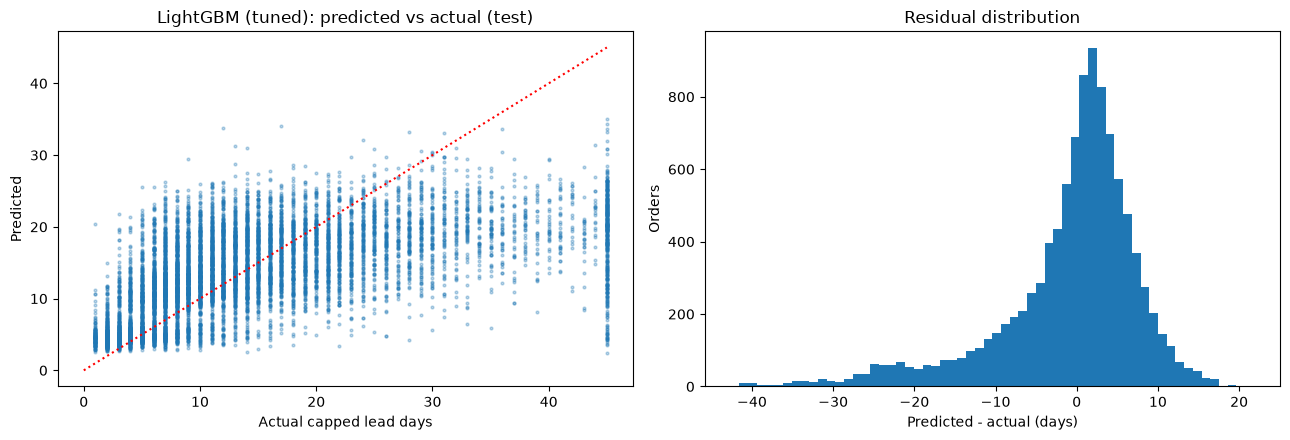

In [14]:
residuals = test_df[['customer_state', 'route_type']].copy()
residuals['actual'] = y_test.to_numpy()
residuals['predicted'] = test_predictions[champion_key]
residuals['error'] = residuals['predicted'] - residuals['actual']
for segment in ['route_type', 'customer_state']:
    table = residuals.groupby(segment).agg(orders=('error', 'size'), actual_mean=('actual', 'mean'),
                                           predicted_mean=('predicted', 'mean'), bias=('error', 'mean'),
                                           mae=('error', lambda e: e.abs().mean()))
    display(table.sort_values('orders', ascending=False).head(12))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(residuals['actual'], residuals['predicted'], s=4, alpha=0.3)
axes[0].plot([0, HORIZON], [0, HORIZON], color='red', linestyle=':')
axes[0].set(xlabel='Actual capped lead days', ylabel='Predicted', title=f'{champion_label}: predicted vs actual (test)')
axes[1].hist(residuals['error'], bins=60)
axes[1].set(xlabel='Predicted - actual (days)', ylabel='Orders', title='Residual distribution')
plt.tight_layout()
plt.show()

# Dual framing: a late flag derived from the regression output
An order is flagged late when the champion's **predicted lead time exceeds the promised lead time**. This is the same outcome as the classification label.

The table compares this flag on the same chronological test set with:
- a LightGBM classifier trained on the same features and split, at a 0.5 threshold;
- a Logistic Regression classifier.

It also checks what the new features add to the classifier. PR-AUC is compared with the base feature set (`NUM_COLS + CAT_COLS`) and with the extended one.

In [15]:
# A few orders have a lead-time target but no late label yet (promised date still ahead)
test_known, train_known = test_df['late_label'].notna(), train_df['late_label'].notna()
print(f'Orders without a known late label (excluded here): train {(~train_known).sum()}, test {(~test_known).sum()}')
cls_train, cls_test = train_df[train_known], test_df[test_known]
test_late = cls_test['late_label'].astype(int)
train_late = cls_train['late_label'].astype(int)
margin = (test_predictions[champion_key][test_known.to_numpy()]
          - np.clip(cls_test['promised_lead_days'].to_numpy(dtype=float), 0, HORIZON))
dual_rows = {'Regression-derived flag': classification_metrics(test_late, (margin > 0).astype(int), margin)}

def fit_classifier(model, num_cols, scale):
    preprocessor = ColumnTransformer([
        ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median'))]
                             + ([('scaler', StandardScaler())] if scale else [])), num_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), CAT_COLS)], sparse_threshold=0)
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(cls_train[num_cols + CAT_COLS], train_late)
    prob = pipeline.predict_proba(cls_test[num_cols + CAT_COLS])[:, 1]
    return classification_metrics(test_late, (prob >= 0.5).astype(int), prob)

ratio = (train_late == 0).sum() / (train_late == 1).sum()
for label, cols in [('v2 features', NUM_COLS), ('v2 + extra features', REG_NUM_COLS)]:
    dual_rows[f'LightGBM classifier ({label})'] = fit_classifier(
        LGBMClassifier(scale_pos_weight=ratio, random_state=RANDOM_STATE, verbosity=-1), cols, scale=False)
    dual_rows[f'LogisticRegression ({label})'] = fit_classifier(
        LogisticRegression(class_weight='balanced', max_iter=2000, random_state=RANDOM_STATE), cols, scale=True)
print(f'Test late rate: {test_late.mean():.2%}')
display(pd.DataFrame(dual_rows).T)

Orders without a known late label (excluded here): train 0, test 1


Test late rate: 15.23%


,accuracy,balanced_accuracy,precision,recall,f1_score,roc_auc,pr_auc
Regression-derived flag,0.851,0.539,0.579,0.089,0.155,0.698,0.337
LightGBM classifier (v2 features),0.439,0.613,0.196,0.863,0.319,0.676,0.256
LogisticRegression (v2 features),0.711,0.632,0.268,0.518,0.353,0.669,0.252
LightGBM classifier (v2 + extra features),0.587,0.656,0.234,0.755,0.357,0.723,0.332
LogisticRegression (v2 + extra features),0.696,0.668,0.279,0.628,0.386,0.723,0.335


# Pooled monthly backtest on a moving window, April–July 2018
This follows the classification notebook's inference flow. The training window moves forward one month at a time:
1. On the 2nd of each month, take that run date's own 180-day window. It ends 45 days before the inference date, so every capped target in it is known.
2. **Re-select the champion as of that run date.** The window gets the same 45-day chronological split and 5 CV folds as above, and the candidate with the lowest CV MAE becomes that month's champion.
3. Refit every candidate on the whole window and score every order approved that month. The `Champion` row uses that month's champion's predictions.
4. Evaluate each daily cohort once its capped target is known, at approval day + `HORIZON`.

The hyperparameters were chosen using approvals up to the end of the CV training part (early March 2018), so none of these months was used for tuning. The delivery data ends in mid-October 2018, so July 2018 is the last month that can be fully evaluated.

In [16]:
def backtest_month(run_date):
    start, end, _ = get_required_dates(run_date, lookback=LOOKBACK, pXd=PXD, verbose=False)
    history = final_df[final_df['order_approved_dt'].between(start, end)
                       & ~final_df['order_status'].isin(EXCLUDED_STATUSES)]
    targets = regression_targets_as_of(history, run_date=run_date, horizon=HORIZON)
    targets = targets[targets['target_as_of_run'].notna()]
    targets = targets.assign(y=targets['target_as_of_run'].astype(float))

    # Champion as of this run date: same split and folds as above, on this window only
    month_train, _ = chronological_split(targets, date_col='order_approved_dt', test_days=TEST_DAYS)
    month_train = month_train.sort_values('order_approved_dt', kind='stable')
    month_folds = day_blocked_time_series_folds(month_train['order_approved_dt'], n_splits=N_CV_FOLDS)
    month_cv_mae = {key: cv_summary(model, month_train[REG_FEATURE_COLS], month_train['y'],
                                    month_folds, n_jobs=1)['cv_mae_mean']
                    for key, model in candidate_models.items()}
    month_champion = select_champion(month_cv_mae)

    month = pd.Period(run_date, 'M')
    cohort = final_df[final_df['order_approved_dt'].dt.to_period('M').eq(month)]
    frames = []
    for (name, variant), model in scored_models.items():
        fitted = clone(model).fit(targets[REG_FEATURE_COLS], targets['y'])
        frame = cohort[['order_id', 'order_approved_dt']].copy()
        frame['predicted'] = np.clip(fitted.predict(cohort[REG_FEATURE_COLS]), 0, HORIZON)
        frame['model'], frame['variant'], frame['month'] = name, variant, str(month)
        frames.append(frame)
        if (name, variant) == month_champion:
            frames.append(frame.assign(model='Champion', variant='re-selected monthly'))
    champion_row = {'month': str(month), 'train_orders': len(targets),
                    'champion': f'{month_champion[0]} ({month_champion[1]})',
                    'champion_cv_mae': month_cv_mae[month_champion]}
    return pd.concat(frames, ignore_index=True), champion_row

backtest_runs = Parallel(n_jobs=-1)(delayed(backtest_month)(d) for d in BACKTEST_RUN_DATES)
backtest = pd.concat([predictions for predictions, _ in backtest_runs], ignore_index=True)
backtest_actuals = attach_regression_actuals(backtest[['order_id']].drop_duplicates(), orders,
                                             horizon=HORIZON)
backtest = backtest.merge(backtest_actuals[['order_id', 'actual_target', 'target_status']], on='order_id')
known_orders = backtest_actuals['actual_target'].notna()
print(f'April-July backtest orders: known capped targets at approval day + {HORIZON} days: '
      f'{known_orders.sum():,}/{len(backtest_actuals):,} ({known_orders.mean():.2%})')

April-July backtest orders: known capped targets at approval day + 45 days: 26,166/26,184 (99.93%)


In [17]:
def backtest_metrics(group):
    known = group[group['actual_target'].notna()]
    return pd.Series(regression_metrics(known['actual_target'].astype(float), known['predicted']))

backtest_monthly = backtest.groupby(['month', 'model', 'variant']).apply(backtest_metrics).reset_index()

# Which candidate actually scored best each month, to check the champion picks
candidates_monthly = backtest_monthly[backtest_monthly['variant'].isin(['default', 'tuned'])]
hindsight = candidates_monthly.loc[candidates_monthly.groupby('month')['mae'].idxmin()].set_index('month')
champions = pd.DataFrame([row for _, row in backtest_runs]).set_index('month')
champions['champion_backtest_mae'] = (backtest_monthly[backtest_monthly['model'].eq('Champion')]
                                      .set_index('month')['mae'])
champions['best_in_hindsight'] = hindsight['model'] + ' (' + hindsight['variant'] + ')'
champions['best_in_hindsight_mae'] = hindsight['mae']
print('Champion at each run date:')
display(champions)

print('MAE by month:')
display(backtest_monthly.pivot_table(index=['model', 'variant'], columns='month', values='mae'))
print('Equal-weight monthly mean and std:')
display(backtest_monthly.groupby(['model', 'variant'])[['mae', 'rmse', 'r2', 'bias']]
        .agg(['mean', 'std']).sort_values(('mae', 'mean')))
print('Pooled over all four months:')
display(backtest.groupby(['model', 'variant']).apply(backtest_metrics).sort_values('mae'))

Champion at each run date:


,train_orders,champion,champion_cv_mae,champion_backtest_mae,best_in_hindsight,best_in_hindsight_mae
month,,,,,,
2018-04,33847,LightGBM (tuned),5.226,5.201,Linear Regression (default),4.970
2018-05,37072,LightGBM (tuned),5.587,6.287,LightGBM (tuned),6.287
2018-06,39532,LightGBM (tuned),6.117,4.549,LightGBM (tuned),4.549
2018-07,42621,LightGBM (tuned),6.136,4.402,LightGBM (tuned),4.402


MAE by month:


month                                  2018-04  2018-05  2018-06  2018-07
model             variant                                                
Champion          re-selected monthly    5.201    6.287    4.549    4.402
Decision Tree     default                8.328    9.961    7.373    7.726
                  tuned                  6.420    7.476    6.372    5.314
Dummy (median)    reference              6.450    6.698    5.943    5.954
LightGBM          default                6.076    7.470    5.611    5.290
                  tuned                  5.201    6.287    4.549    4.402
Linear Regression default                4.970    6.790    6.946    4.860
Olist promise     reference             13.820   13.020   19.307   12.390
Random Forest     default                6.259    7.273    6.240    5.516
                  tuned                  6.184    7.231    5.956    5.458
Ridge             default                5.547    6.501    6.922    4.927
                  tuned                  5.641    6.402    6.986    5.249

Equal-weight monthly mean and std:


mae         rmse           r2        \
                                        mean   std   mean   std   mean   std   
model             variant                                                      
Champion          re-selected monthly  5.110 0.858  7.664 0.747  0.135 0.109   
LightGBM          tuned                5.110 0.858  7.664 0.747  0.135 0.109   
Linear Regression default              5.891 1.130  8.254 0.466 -0.033 0.300   
Ridge             default              5.974 0.905  8.218 0.375 -0.023 0.295   
                  tuned                6.069 0.776  8.210 0.328 -0.022 0.296   
LightGBM          default              6.112 0.961  8.263 0.922 -0.008 0.168   
Random Forest     tuned                6.207 0.747  8.300 0.717 -0.020 0.160   
Dummy (median)    reference            6.261 0.375  8.482 0.666 -0.057 0.075   
Random Forest     default              6.322 0.722  8.439 0.661 -0.057 0.181   
Decision Tree     tuned                6.396 0.883  8.594 0.757 -0.096 0.194   
                  default              8.347 1.146 12.389 1.231 -1.270 0.371   
Olist promise     reference           14.634 3.170 16.390 3.046 -3.355 2.751   

                                        bias        
                                        mean   std  
model             variant                           
Champion          re-selected monthly  1.369 1.109  
LightGBM          tuned                1.369 1.109  
Linear Regression default              2.024 2.766  
Ridge             default              2.451 2.121  
                  tuned                2.774 1.770  
LightGBM          default              3.215 1.192  
Random Forest     tuned                3.325 0.997  
Dummy (median)    reference            1.270 1.439  
Random Forest     default              3.418 1.063  
Decision Tree     tuned                3.399 1.271  
                  default              3.971 0.998  
Olist promise     reference           13.271 3.651

Pooled over all four months:


mae   rmse     r2  median_ae   bias
model             variant                                                   
Champion          re-selected monthly  5.152  7.726  0.160      3.589  1.397
LightGBM          tuned                5.152  7.726  0.160      3.589  1.397
Linear Regression default              5.901  8.270  0.038      4.476  2.015
Ridge             default              5.983  8.226  0.048      4.675  2.441
                  tuned                6.071  8.214  0.051      4.877  2.745
LightGBM          default              6.158  8.346  0.020      4.784  3.250
Random Forest     tuned                6.242  8.358  0.017      5.014  3.345
Dummy (median)    reference            6.281  8.530 -0.024      5.000  1.209
Random Forest     default              6.354  8.490 -0.014      5.069  3.432
Decision Tree     tuned                6.434  8.656 -0.054      5.082  3.425
                  default              8.402 12.494 -1.196      5.000  3.999
Olist promise     reference           14.560 16.525 -2.842     14.000 13.180

## Save tuned parameters and the champion

In [18]:
os.makedirs('results', exist_ok=True)
regression_output = {
    'run_date': RUN_DATE, 'horizon_days': HORIZON, 'test_days': TEST_DAYS,
    'cv': f'{N_CV_FOLDS}-fold day-blocked expanding window',
    'scoring': 'neg_mean_absolute_error',
    'champion': {'model': champion_name, 'variant': champion_variant,
                 'cv_mae': cv_results.loc[champion_key, 'cv_mae_mean']},
    'backtest_champions': champions['champion'].to_dict(),
    'models': {name: {'family': MODEL_FAMILY[name], 'best_params': best_params.get(name, {}),
                      'cv_mae_default': cv_results.loc[(name, 'default'), 'cv_mae_mean'],
                      'cv_mae_tuned': (cv_results.loc[(name, 'tuned'), 'cv_mae_mean']
                                       if name in tuned_models else None)}
               for name in default_models},
}
with open('results/regression_tuning.json', 'w') as f:
    json.dump(regression_output, f, indent=2)
print('Saved results/regression_tuning.json')

Saved results/regression_tuning.json


## Findings (fixed seeds; numbers from this run, run date 2018-06-02)
1. **Champion: tuned LightGBM (L1 objective), CV MAE ≈ 6.12 days.**
   - Tuned Random Forest (6.23) and default LightGBM (6.25) are close behind. That 0.11–0.13 day lead is smaller than the fold-to-fold standard deviation (≈ 0.4–0.6), so on CV alone the top three are within noise.
   - The hold-out and the backtest separate them more clearly: 6.10 days on the hold-out versus 6.40 for the next model, and 5.15 pooled over April–July versus 5.90.
2. **The champion did not change as the window moved.**
   - Tuned LightGBM was re-selected at all four run dates (CV MAE 5.2–6.1 on each month's own window).
   - It was also the best candidate in hindsight in May, June and July. In April, Linear Regression scored 4.97 against the champion's 5.20.
3. **A random split flatters the scores.** For default LightGBM, random 5-fold CV gives MAE 5.87 and R² 0.34, versus 6.25 and 0.24 for time-series CV. The report should quote the time-series numbers.
4. **Tuning matters most where the default is poor.**
   - Decision Tree gains 2.3 days of CV MAE once depth and leaf size are limited. The unlimited default (≈ 8.7) is worse than the Dummy median (≈ 7.6).
   - Ridge, Random Forest and LightGBM gain 0.1–0.4 days, less than their fold standard deviation.
   - In the backtest, tuned LightGBM beats default LightGBM by about one day (5.15 vs 6.16). Most of that comes with a lower bias (+1.4 vs +3.3 days) under the L1 objective. Tuned Ridge is slightly worse than default Ridge there (6.07 vs 5.98).
5. **CV ranking of the families transfers only partly.**
   - On CV the linear models are weak and unstable (MAE 7.5–7.9, standard deviation 1.6–1.8). On the hold-out and in the backtest they come second, ahead of Random Forest.
   - Only the champion clearly beats the Dummy median in the backtest (5.15 vs 6.28). Every other candidate is within about 0.4 days of it, or worse.
6. **Olist's promise is a poor lead-time estimate.** Its MAE is 11.3 days on the hold-out and 14.6 in the backtest, with a +13-day bias, because Olist pads its estimates. The champion is 5–9 days closer.
7. **Key drivers:** route type, customer state, promised lead days and seller distance. Errors are largest for interstate routes and for RJ and CE. The champion under-predicts BA, CE and ES by about 3 days.
8. **R² is modest:** 0.34 on the hold-out and 0.16 pooled in the backtest. Lead time has a heavy tail driven by events outside the data. State the stakeholder value in terms of MAE (days), not R².
9. **Dual framing.**
   - The regression-derived late flag is precise but misses most late orders at its natural cut-off (precision 0.58, recall 0.09). As a ranking it matches the classifiers (PR-AUC 0.34 vs 0.33).
   - The extra features raise classifier PR-AUC for both families (0.25 → 0.33).

# Next steps (not done yet)
- **Seller/state history features, computed as of the run date.** Examples: seller median lead time and seller late rate over prior labelled orders. Build them from `regression_targets_as_of` / `labels_as_of` using a history window that ends before each training row's own label is known. Otherwise they leak.
- **A margin for the derived late flag.** Flag an order when the predicted lead time comes within a few days of the promise, or use a capacity rule, instead of the zero cut-off.
- **Optional stacking.** Build a Ridge + LightGBM `StackingRegressor` and add it as a candidate, so it has to win the champion selection like any other model.
- **Team decisions:**
  - The classification notebook still holds out 30 days (`TUNING_TEST_DAYS`); this notebook now holds out 45. Align them or state the difference.
  - Confirm how canceled/unavailable orders are handled.
- **Report limitations:**
  - The capped target hides detail beyond 45 days (~1% of orders).
  - Estimated dates are assumed fixed.
  - The dataset holds only final order statuses.
  - The May 2018 truckers' strike month.
  - Hyperparameters are tuned once, at the 2018-06-02 run date, and reused at every backtest run date. Only the champion choice is refreshed.